# **CA4 @ AI Spring 2025**
# Convolutional vs. Fully Connected Neural Networks

- **Name:** Mohammad Hossein Mazaheri
- **Student ID:** 810102585

---
Your submission should be named using the following format: `AI_CA4_LASTNAME_STUDENTID.ipynb`.

---

 *How to do this problem set:*

- Some questions require writing Python code and computing results, and the rest of them have written answers. For coding problems, you will have to fill out all code blocks that say `YOUR CODE HERE`.

- For text-based answers, you should replace the text that says `WRITE YOUR ANSWER HERE` with your actual answer.
---
If you have any further questions or concerns, contact the TAs via email or Telegram.

# Introduction
In this assignment, you will compare fully connected neural networks with convolutional neural networks to evaluate whether convolutional architectures offer superior performance—and understand the reasons behind any observed differences.

**Important Note:**

Before you begin, please make sure to review the accompanying PyTorch tutorial provided alongside this file.

## Colab Setup

If you are running this notebook on Google Colab, you can mount your Google Drive using the following code to access or upload files directly from your Drive.

In [1]:
# from google.colab import drive
# import os

# drive.mount('/content/drive')

# GOOGLE_DRIVE_PATH = os.path.join('drive', 'My Drive', 'AIS25-CA4')
# os.chdir(GOOGLE_DRIVE_PATH)

## Device

As demonstrated in the PyTorch tutorial, PyTorch enable you to run your code on GPU to accelerate computations.

In [2]:
import torch
print(torch.version.cuda)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

12.4


'cuda'

# Dataset

## Transforms & Dataset & Dataloader

Here, you should download and load the dataset with the desire transforms. After that, you should split train dataset to train and validation sets. Finally, define the dataloaders for `train`, `validation` and `test`

In [3]:
classes = ['plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

In [4]:
from torchvision import transforms

transform_train = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.491, 0.482, 0.446), (0.247, 0.243, 0.261)),
])

In [5]:
from torch.utils.data import random_split
from torch.utils.data import DataLoader
import torchvision

batch_size = 512

initial_trainset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train)
testset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test)

trainset, valset = random_split(initial_trainset, [45000, 5000])

trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=False, num_workers=2)
valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

100%|██████████| 170M/170M [00:13<00:00, 12.3MB/s]


## Visualization

Visualize 5 random images from each class in different columns

- **Hint**:  You can use `plt.subplots` for visualization

In [6]:
# inverse the normilize transform to restore the original data
import torch

class UnNormalize(object):
    def __init__(self, mean, std):
        self.mean = torch.tensor(mean)
        self.std = torch.tensor(std)

    def __call__(self, tensor, gray=False, coeff=(0.3, 0.59, 0.11)):
        """
        Args:
            tensor (Tensor): Tensor image of size (C, H, W) to be unnormalized.
        Returns:
            Tensor: Unnormalized image.
        """
        C, H, W = tensor.shape
        mean_expanded = self.mean.unsqueeze(1).unsqueeze(2).expand(C, H, W)
        std_expanded = self.std.unsqueeze(1).unsqueeze(2).expand(C, H, W)

        tensor = tensor * std_expanded + mean_expanded

        tensor = torch.clamp(tensor, 0, 1)

        if gray:
            r, g, b = tensor[0], tensor[1], tensor[2]
            weights = torch.tensor(coeff).to(tensor.device)
            grayscale = (r * weights[0] + g * weights[1] + b * weights[2])
            tensor = grayscale.unsqueeze(0)

        return tensor

norminv = UnNormalize(mean=(0.491, 0.482, 0.446), std=(0.247, 0.243, 0.261))

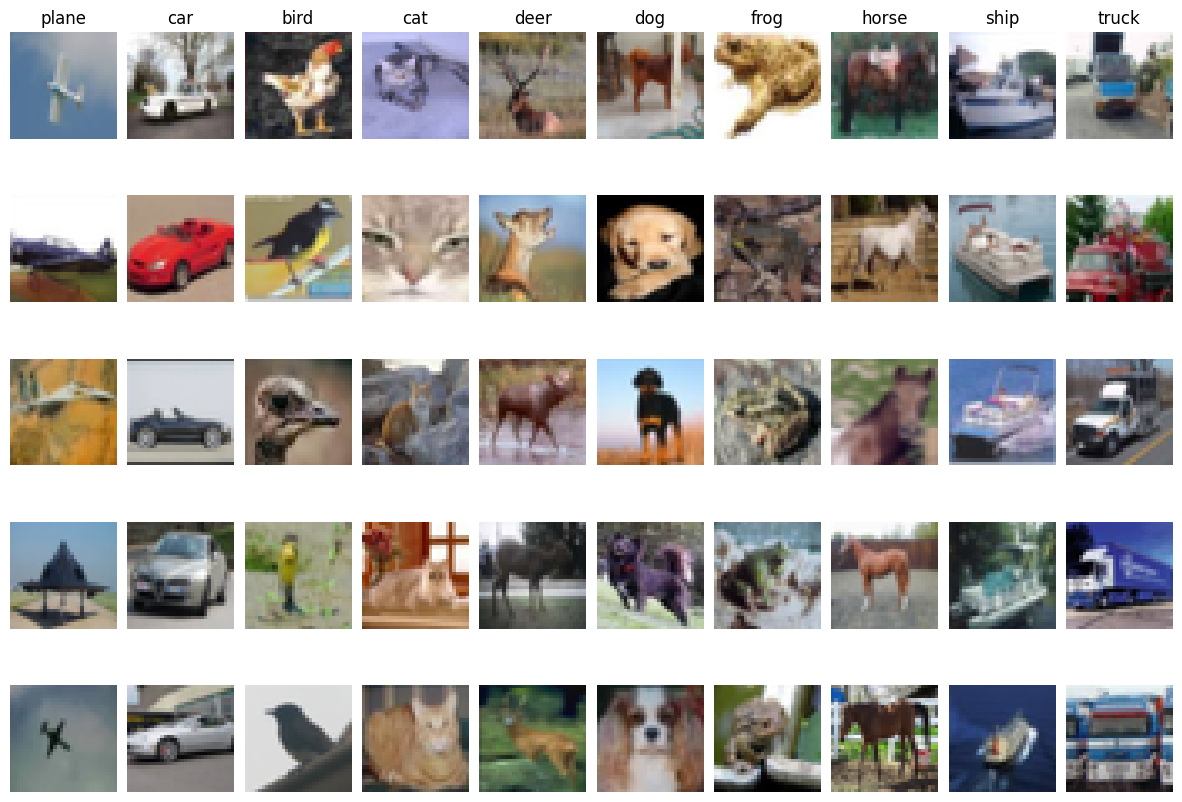

In [7]:
import matplotlib.pyplot as plt
import numpy as np
from torchvision.datasets import CIFAR10

dataset = CIFAR10(root='./data', train=True, download=True)

numClasses = len(classes)
numExamples = 5
fig, axes = plt.subplots(numExamples, numClasses, figsize=(15, 10))
fig.subplots_adjust(hspace=0.4, wspace=0.1)

for class_idx, class_name in enumerate(classes):
    class_indices = np.where(np.array(dataset.targets) == class_idx)[0]
    selected_indices = np.random.choice(class_indices, numExamples, replace=False)

    for row_idx, img_idx in enumerate(selected_indices):
        img, _ = dataset[img_idx]
        axes[row_idx, class_idx].imshow(img)
        axes[row_idx, class_idx].axis('off')
        if row_idx == 0:
            axes[row_idx, class_idx].set_title(class_name)

plt.show()

# Fully Connected Neural Netwrok

Your first task is to build a fully connected neural network with PyTorch. To achieve this, it is recommended that you familiarize yourself with the following PyTorch components and incorporate them into your network architecture:

* [`nn.Module`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Module.html)
* [`nn.Sequential`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Sequential.html)
* [`nn.Linear`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Linear.html)
* [`nn.ReLU`](https://docs.pytorch.org/docs/stable/generated/torch.nn.ReLU.html)
* [`nn.Dropout`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Dropout.html)
* [`nn.Flatten`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Flatten.html)

In the provided template below, the final layer of the model should be defined separately and assigned the name `linear`, as it will be referenced in a later section of this assignment.

To ensure a fair comparison with convolutional neural networks (CNNs), both models should have approximately the same number of trainable parameters. Specifically, the fully connected model should contain **33,500,000 ± 500,000** trainable parameters.

You will calculate the exact number of trainable parameters in the following subsection to ensure this requirement is met.




In [8]:
import torch
import numpy as np
import torchvision
import torch.nn as nn
import math
from torchvision import transforms

class FullyConnectedNetwork(nn.Module):
    def __init__(self, input_shape=(3, 32, 32), num_classes=10):
        super(FullyConnectedNetwork, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            nn.Linear(3 * 32 * 32, 5200),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(5200, 2600),
            nn.ReLU(),
            nn.Dropout(0.4),
            nn.Linear(2600, 1722),
            nn.ReLU(),
            nn.Dropout(0.5)
            )

        self.linear =nn.Linear(1722, num_classes)

    def forward(self, x):
        x = self.model(x)
        predict = self.linear(x)
        return predict

## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

`WRITE YOUR ANSWER HERE`

Once you have completed your hand calculation, you can verify your result by running the following cell:

In [9]:
from torchsummary import summary
summary(FullyConnectedNetwork().to(device), input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
           Flatten-1                 [-1, 3072]               0
            Linear-2                 [-1, 5200]      15,979,600
              ReLU-3                 [-1, 5200]               0
           Dropout-4                 [-1, 5200]               0
            Linear-5                 [-1, 2600]      13,522,600
              ReLU-6                 [-1, 2600]               0
           Dropout-7                 [-1, 2600]               0
            Linear-8                 [-1, 1722]       4,478,922
              ReLU-9                 [-1, 1722]               0
          Dropout-10                 [-1, 1722]               0
           Linear-11                   [-1, 10]          17,230
Total params: 33,998,352
Trainable params: 33,998,352
Non-trainable params: 0
----------------------------------------------------------------
Input size (MB): 0.01
Fo

## Train

### Model Instantiation

Create an instance of your model and move it to your selected device (CPU or GPU). Refer to the PyTorch-tutorial notebook for guidance on how to perform this operation.

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = FullyConnectedNetwork(input_shape=(3, 32, 32), num_classes=10).to(device)

### Criterion & Optimizer


To train a neural network, we require a **loss function** (referred to as the *criterion*) to quantify the difference between the model's predictions and the true labels. This loss is then used to compute the gradients of the model parameters.

In addition, an **optimization algorithm** is needed to update the model's parameters using the calculated gradients, in order to minimize the loss over time.

You are encouraged to read about the following PyTorch components:

* [`nn.CrossEntropyLoss`](https://docs.pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html)
* [`torch.optim.Adam`](https://docs.pytorch.org/docs/stable/generated/torch.optim.Adam.html)

In [11]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5) #lr is learning rate

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [12]:
def train_epoch(net: torch.nn.Module, criterion: torch.nn.Module, optimizer: torch.optim.Optimizer ,dataloader: torch.utils.data.DataLoader):
    """
    Trains the neural network for a single epoch.

    Args:
        net (torch.nn.Module): The neural network model to be trained.
        criterion (torch.nn.Module): The loss function used to compute the training loss.
        optimizer (torch.optim.Optimizer): The optimization algorithm used to update model parameters.
        dataloader (torch.utils.data.DataLoader): DataLoader providing the training data in batches.

    Returns:
        tuple:
            - avg_loss (float): The average loss across all batches in the epoch.
            - accuracy (float): The classification accuracy (in percentage) over the entire dataset for the epoch.

    Notes:
        - The `criterion` computes the loss between the model's predictions and the true labels.
        - The `optimizer` updates the model's parameters based on the computed gradients to minimize the loss.
    """
    net.train()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    for batch_idx, (inputs, targets) in enumerate(dataloader):
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = net(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        total_loss = total_loss + loss.item() * inputs.size(0)
        i, predicted = outputs.max(1)
        correct = correct + predicted.eq(targets).sum().item()
        total_samples = total_samples + targets.size(0)

    avg_loss = total_loss / total_samples
    accuracy = 100. * correct / total_samples
    return avg_loss, accuracy

def eval_epoch(net: torch.nn.Module, criterion: torch.nn.Module, dataloader: torch.utils.data.DataLoader, test_mode: bool = False):
    """
    Evaluates the neural network on a validation or test dataset for one epoch.
    """
    net.eval()
    total_loss = 0.0
    correct = 0
    total_samples = 0

    with torch.no_grad():
        for batch_idx, (inputs, targets) in enumerate(dataloader):
            inputs, targets = inputs.to(device), targets.to(device)

            outputs = net(inputs)
            loss = criterion(outputs, targets)

            total_loss = total_loss + loss.item() * inputs.size(0)
            i, predicted = outputs.max(1)
            correct = correct + predicted.eq(targets).sum().item()
            total_samples = total_samples + targets.size(0)

    avg_loss = total_loss / total_samples
    accuracy = 100. * correct / total_samples
    return avg_loss, accuracy

As previously mentioned, ensuring a fair comparison between models requires consistency in certain aspects of the training setup. One key factor is the number of **trainable parameters**, and another is the number of times the model processes the entire dataset—referred to as an **epoch**.

To maintain consistency in training duration across models, **do not modify** the `epochs` variable defined below.


In [13]:
epochs = 30 # Do not modify

history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}


for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader)
    val_loss, val_acc = eval_epoch(model, criterion, valloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 30) train loss: 1.8042; train acc: 35.73%; val loss: 1.5813; val_acc: 43.84%
(Epoch 2 / 30) train loss: 1.5569; train acc: 45.26%; val loss: 1.4779; val_acc: 47.98%
(Epoch 3 / 30) train loss: 1.4464; train acc: 49.00%; val loss: 1.4215; val_acc: 50.14%
(Epoch 4 / 30) train loss: 1.3598; train acc: 52.20%; val loss: 1.3700; val_acc: 52.08%
(Epoch 5 / 30) train loss: 1.2906; train acc: 54.87%; val loss: 1.3370; val_acc: 53.60%
(Epoch 6 / 30) train loss: 1.2268; train acc: 57.15%; val loss: 1.3131; val_acc: 54.62%
(Epoch 7 / 30) train loss: 1.1669; train acc: 59.05%; val loss: 1.3003; val_acc: 54.18%
(Epoch 8 / 30) train loss: 1.1066; train acc: 61.05%; val loss: 1.2919; val_acc: 55.08%
(Epoch 9 / 30) train loss: 1.0566; train acc: 63.28%; val loss: 1.2996; val_acc: 55.44%
(Epoch 10 / 30) train loss: 0.9994; train acc: 65.01%; val loss: 1.2939; val_acc: 55.68%
(Epoch 11 / 30) train loss: 0.9507; train acc: 66.63%; val loss: 1.3176; val_acc: 55.88%
(Epoch 12 / 30) train loss: 0.

### Save Model

Save the trained model for use in subsequent sections to avoid retraining it later.


In [14]:
torch.save(model.state_dict(), "fully-connected.pth")

In [15]:
# To load the previously saved model, simply uncomment the code below.
# model.load_state_dict(torch.load('fully-connected.pth'))

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

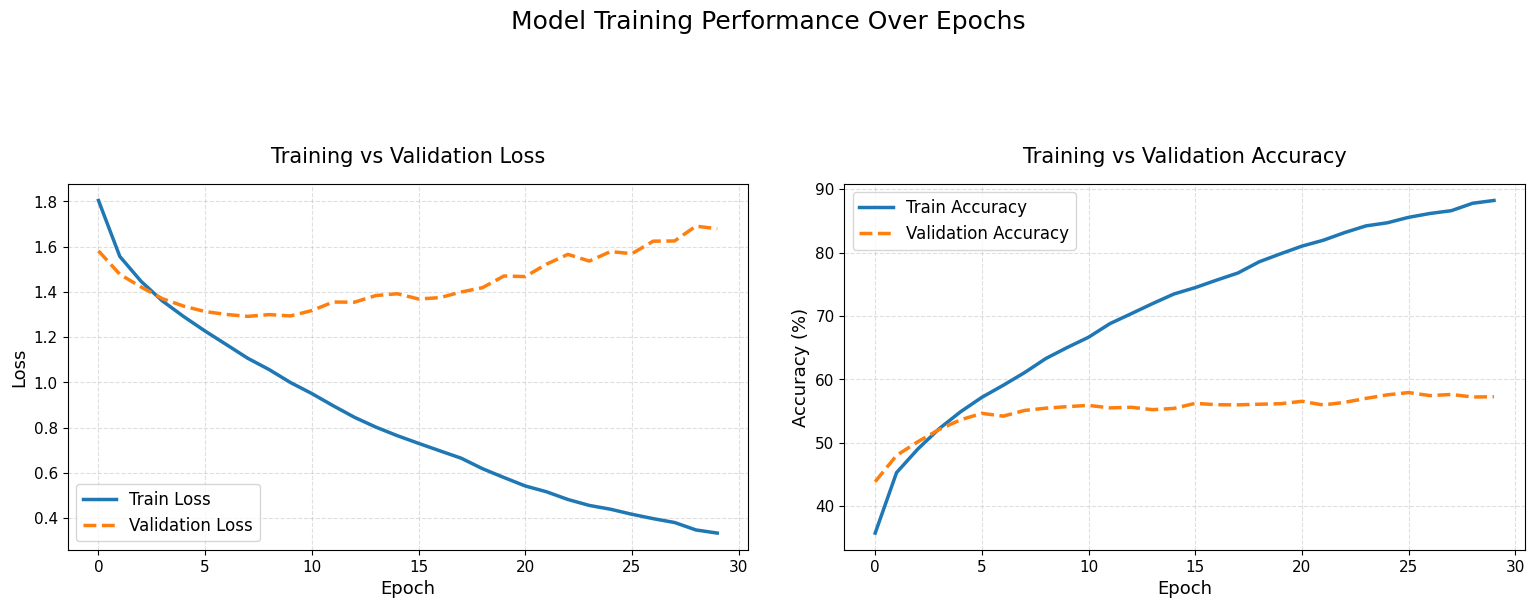

In [16]:
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-muted')

fig, axs = plt.subplots(1, 2, figsize=(16, 6))

train_color = '#1f77b4'
val_color = '#ff7f0e'

axs[0].plot(history['train_loss'], color=train_color, linewidth=2.5, label='Train Loss')
axs[0].plot(history['val_loss'], color=val_color, linestyle='--', linewidth=2.5, label='Validation Loss')
axs[0].set_xlabel('Epoch', fontsize=13)
axs[0].set_ylabel('Loss', fontsize=13)
axs[0].set_title('Training vs Validation Loss', fontsize=15, pad=15)
axs[0].legend(fontsize=12)
axs[0].grid(True, linestyle='--', alpha=0.4)
axs[0].tick_params(axis='both', labelsize=11)

axs[1].plot(history['train_acc'], color=train_color, linewidth=2.5, label='Train Accuracy')
axs[1].plot(history['val_acc'], color=val_color, linestyle='--', linewidth=2.5, label='Validation Accuracy')
axs[1].set_xlabel('Epoch', fontsize=13)
axs[1].set_ylabel('Accuracy (%)', fontsize=13)
axs[1].set_title('Training vs Validation Accuracy', fontsize=15, pad=15)
axs[1].legend(fontsize=12)
axs[1].grid(True, linestyle='--', alpha=0.4)
axs[1].tick_params(axis='both', labelsize=11)

fig.suptitle('Model Training Performance Over Epochs', fontsize=18, y=1.05)

plt.tight_layout(pad=3.0)

plt.savefig('training_curves_beautified.png', dpi=300, bbox_inches='tight')
plt.show()


## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `60%`

In [17]:
test_losses, test_accuracy = eval_epoch(model, criterion, testloader, test_mode=True)
print(f"Test Loss: {test_losses:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss: 1.7599
Test Accuracy: 56.09%


# Convolutional Neural Network

## Model

Define your model here from scratch (You are not allowed to use the existing models in pytorch)

**NOTICE:** The model that you will have defined outputs a vector containing 10 numbers (for each class). Define a "feature space" that is a vector of size *N* (where *N > 10*) right before the last layer (You can then have a last layer like `nn.Linear(N, 10)`). See the image below to get a better understanding. We will use this later (we want to access the feature space of a sample when the sample is given to the model). The model tries to learn a representation of the samples in this feature space and we will see how good it could do this in later sections.

![Feature Space In Neural Network](https://i.postimg.cc/28Qjcn9D/feature-space-vis.png)

 You are encouraged to learn about the following core components commonly used in convolutional neural networks:

* [`nn.Conv2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.Conv2d.html)
* [`nn.MaxPool2d`](https://docs.pytorch.org/docs/stable/generated/torch.nn.MaxPool2d.html)

**Reminder**: The model you define should contain 33,500,000 ± 500,000 trainable parameters.

In [18]:
class CNN(nn.Module):
    def __init__(self, num_classes=10):
        super(CNN, self).__init__()

        self.feature_learning = nn.Sequential(
            nn.Conv2d(3, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(128),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(256),
            nn.MaxPool2d(2, 2),

            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.BatchNorm2d(512),
            nn.MaxPool2d(2, 2)
        )

        self.flatten = nn.Flatten()
        self.fc1 = nn.Sequential(
            nn.Linear(512 * 4 * 4, 3380),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.feature_space = nn.Sequential(
            nn.Linear(3380, 512),
            nn.ReLU(),
            nn.Dropout(0.5)
        )

        self.classifier = nn.Linear(512, num_classes)

    def forward(self, x):
        x = self.feature_learning(x)
        x = self.flatten(x)
        x = self.fc1(x)
        features = self.feature_space(x)
        out = self.classifier(features)
        return out

## Trainable params

Based on the defined architecture, manually calculate the total number of trainable parameters:

`WRITE YOUR ANSWER HERE`

Once you have completed your hand calculation, you can verify your result by running the following cell:

In [19]:
from torchsummary import summary
summary(CNN().to(device), input_size=(3, 32, 32))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 128, 32, 32]           3,584
              ReLU-2          [-1, 128, 32, 32]               0
       BatchNorm2d-3          [-1, 128, 32, 32]             256
            Conv2d-4          [-1, 128, 32, 32]         147,584
              ReLU-5          [-1, 128, 32, 32]               0
       BatchNorm2d-6          [-1, 128, 32, 32]             256
         MaxPool2d-7          [-1, 128, 16, 16]               0
            Conv2d-8          [-1, 256, 16, 16]         295,168
              ReLU-9          [-1, 256, 16, 16]               0
      BatchNorm2d-10          [-1, 256, 16, 16]             512
           Conv2d-11          [-1, 256, 16, 16]         590,080
             ReLU-12          [-1, 256, 16, 16]               0
      BatchNorm2d-13          [-1, 256, 16, 16]             512
        MaxPool2d-14            [-1, 25

## Train

### Model instantiation

Create an instance of your model and move it to `device`

In [20]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN(num_classes=10).to(device)

### Criterion & Optimizer

Define `criterion` and `optimizer`

In [21]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001, weight_decay=1e-5) #lr is learning rate

### Train loop

Train your model

Tasks:
- Things that are needed to be printed in each epoch:
  - Number of epoch
  - Train loss
  - Train accuracy
  - Validation loss
  - Validation accuracy
- save train/validation loss and accuracy (of each epoch) in an array for later usage

In [22]:
epochs = 30 # Do not modify
history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, criterion, optimizer, trainloader)
    val_loss, val_acc = eval_epoch(model, criterion, valloader)

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)

    print(f"(Epoch {epoch + 1} / {epochs}) train loss:{train_loss: .4f}; train acc:{train_acc: .2f}%; val loss:{val_loss: .4f}; val_acc:{val_acc: .2f}%")

(Epoch 1 / 30) train loss: 1.4249; train acc: 48.07%; val loss: 1.0192; val_acc: 62.50%
(Epoch 2 / 30) train loss: 0.9427; train acc: 66.50%; val loss: 0.8503; val_acc: 69.32%
(Epoch 3 / 30) train loss: 0.7158; train acc: 74.80%; val loss: 0.7187; val_acc: 74.90%
(Epoch 4 / 30) train loss: 0.5411; train acc: 81.33%; val loss: 0.6809; val_acc: 76.84%
(Epoch 5 / 30) train loss: 0.4141; train acc: 85.63%; val loss: 0.7454; val_acc: 76.60%
(Epoch 6 / 30) train loss: 0.3025; train acc: 89.41%; val loss: 0.7197; val_acc: 78.40%
(Epoch 7 / 30) train loss: 0.2362; train acc: 91.83%; val loss: 0.8651; val_acc: 76.26%
(Epoch 8 / 30) train loss: 0.1862; train acc: 93.59%; val loss: 0.9320; val_acc: 75.22%
(Epoch 9 / 30) train loss: 0.1318; train acc: 95.44%; val loss: 0.8353; val_acc: 78.82%
(Epoch 10 / 30) train loss: 0.1001; train acc: 96.50%; val loss: 0.8619; val_acc: 79.60%
(Epoch 11 / 30) train loss: 0.0754; train acc: 97.42%; val loss: 0.7948; val_acc: 80.18%
(Epoch 12 / 30) train loss: 0.

### Save Model

Since changes need to be made to the model later on, it is advisable to save your model to avoid having to retrain it in case of any issues.

In [23]:
torch.save(model.state_dict(), "cnn.pth")

In [24]:
# To load the previously saved model, simply uncomment the code below.
# model.load_state_dict(torch.load('cnn.pth'))

### Visualize Loss and Accuracy plot

Using the arrays that you have (from task 2 in the above section), visualize two plots: Accuracy plot (train and validation together) and Loss plot (train and validation together)

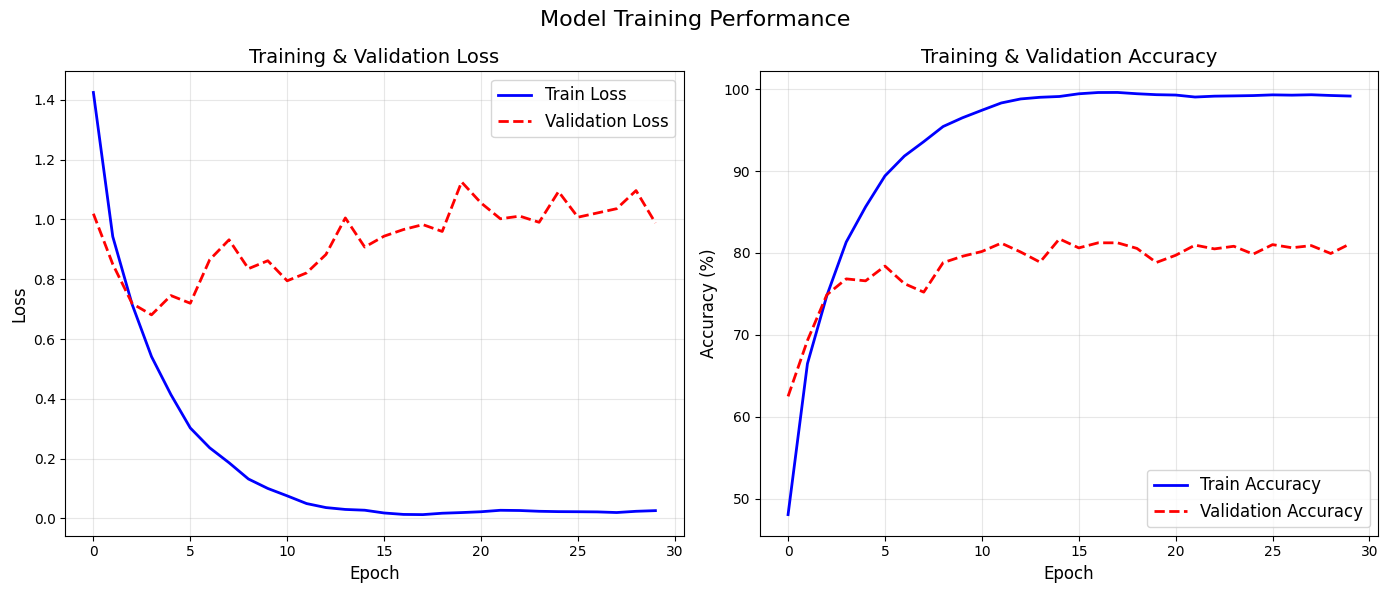

In [25]:
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history['val_loss'], label='Validation Loss', color='red', linestyle='--', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training & Validation Loss', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history['train_acc'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history['val_acc'], label='Validation Accuracy', color='red', linestyle='--', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('Training & Validation Accuracy', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.3)

plt.suptitle('Model Training Performance', fontsize=16)
plt.tight_layout()
plt.show()


## Evaluation

Test your trained model (using the Test Dataloader that you have). Our goal is to reach an accuracy above `80%`

In [26]:
test_losses, test_accuracy = eval_epoch(model, criterion, testloader, test_mode=True)

print(f"Test Loss:     {test_losses:.4f}")
print(f"Test Accuracy: {test_accuracy:.2f}%")

Test Loss:     1.1066
Test Accuracy: 80.15%


## Visualize incorrectly predicted samples from testset

Visualize *24* random images from testset that are incorrectly predicted by the model. Note that if you used normalization in the transform function for loading the data, you will need to unnormalize the images before displaying them.

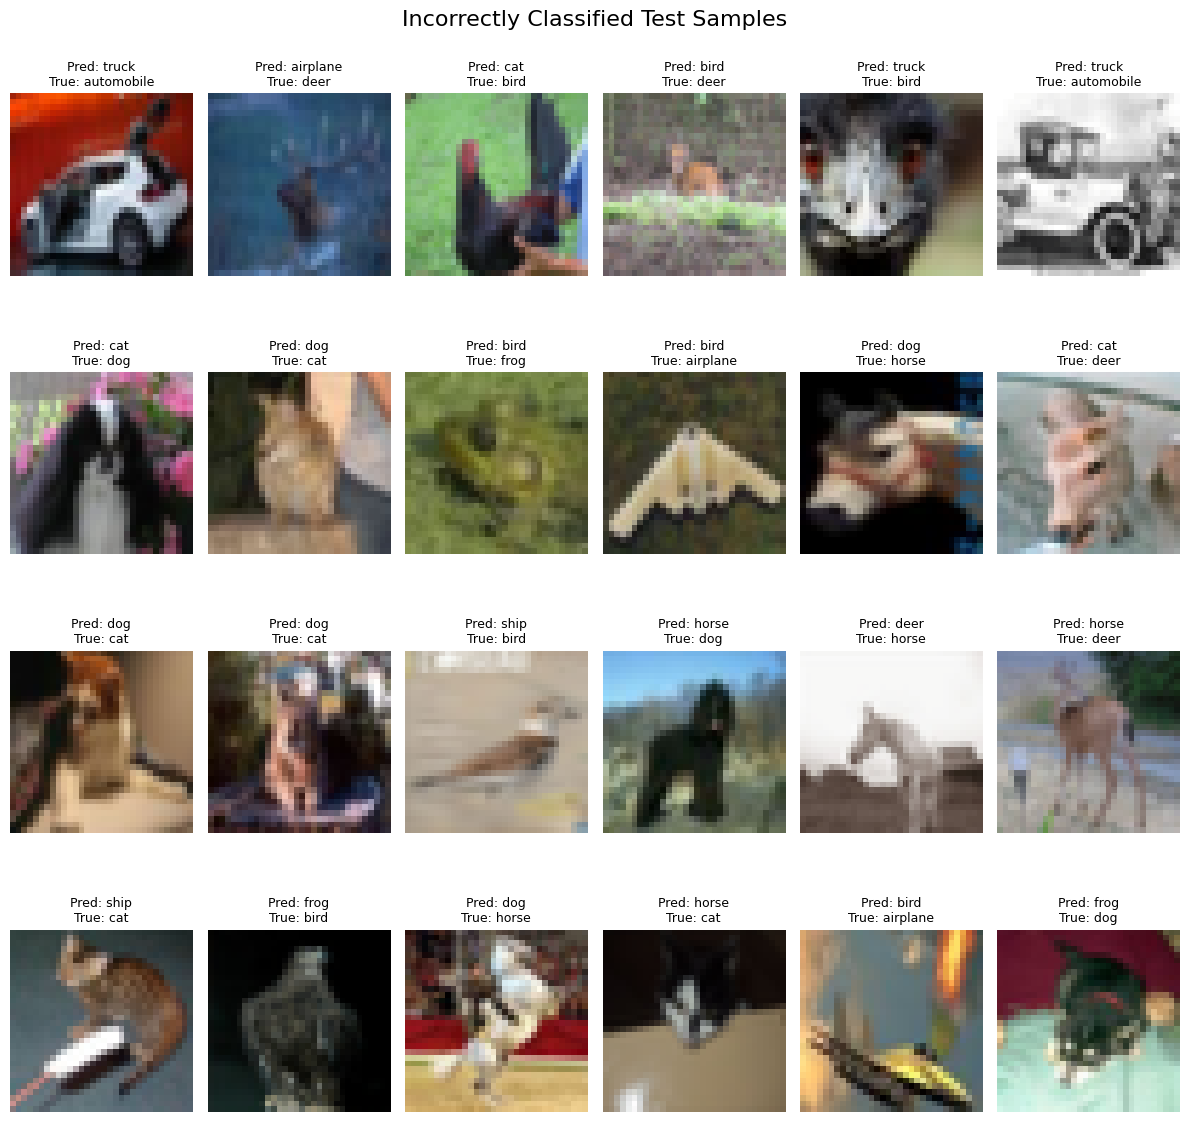

In [27]:
model.eval()
incorrect_samples = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        preds = outputs.argmax(dim=1)
        incorrect = preds != labels

        for img, pred, label, inc in zip(images, preds, labels, incorrect):
            if inc:
                incorrect_samples.append((img.cpu(), pred.item(), label.item()))
            if len(incorrect_samples) >= 24:
                break
        if len(incorrect_samples) >= 24:
            break

plt.figure(figsize=(12, 12))
for i, (img, pred, label) in enumerate(incorrect_samples[:24]):
    img = norminv(img)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.subplot(4, 6, i + 1)
    plt.imshow(img)
    plt.title(f"Pred: {testloader.dataset.classes[pred]}\nTrue: {testloader.dataset.classes[label]}", fontsize=9)
    plt.axis('off')

plt.suptitle("Incorrectly Classified Test Samples", fontsize=16)
plt.tight_layout()
plt.show()


## Exploring the feature space

### Calculate the feature space for all training samples

You have trained and evaluated your model. Now, for each sample in the trainset, calculate it's "feature space" discussed in the model section. The result of this section should be a tensor of size `(45000, N)` saved in a variable (for later usage)

- **Hint:** Pay attension to the `shuffle` attribute of your train dataloader (If needed)

In [29]:
train_loader_noshuffle = torch.utils.data.DataLoader(
    trainset, batch_size=batch_size, shuffle=False, num_workers=2
)

model.eval()
features_list = []

with torch.no_grad():
    for images, _ in train_loader_noshuffle:
        images = images.to(device)

        x = model.feature_learning(images)
        x = model.flatten(x)
        x = model.fc1(x)
        features = model.feature_space(x)
        features_list.append(features.cpu())

train_feature_space = torch.cat(features_list, dim=0)
print("Feature space shape:", train_feature_space.shape)


Feature space shape: torch.Size([45000, 512])


### K Nearest Neighbor in feature space

We already have calculated the feature spaces for trainset ($S$) in the previous section. Now we follow these steps to explore the featre space:

1. Get 5 random samples from testset which are correctly predicted by the model.
2. for each sample, calculate it's "feature space" ($X$)
3. for each sample, calculate it's *5* nearest neighbors in "feature space" in the trainset (by comparing $X$ to each row in $S$) and visualize them

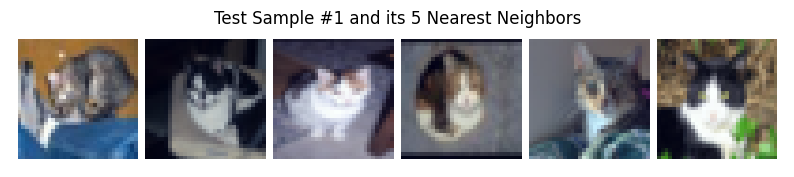

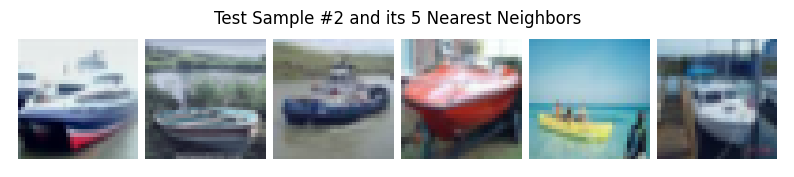

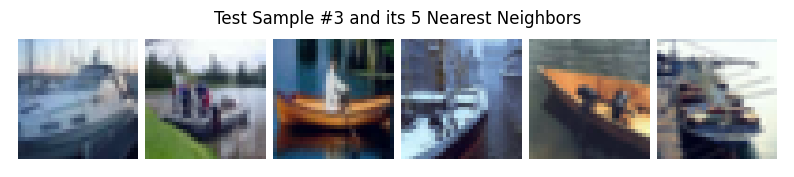

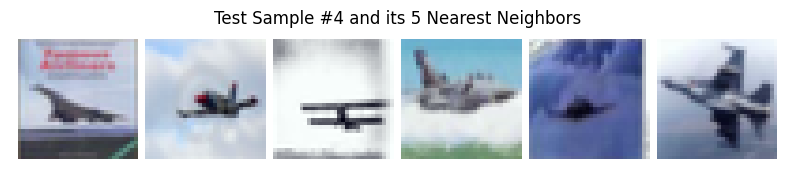

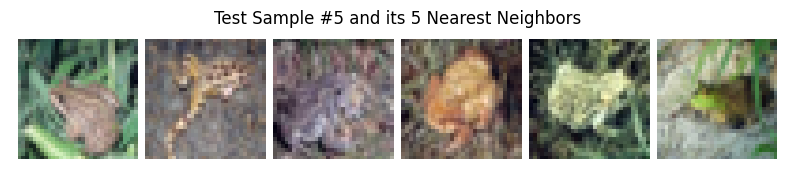

In [31]:
from sklearn.neighbors import NearestNeighbors
from torchvision.utils import make_grid

train_feature_np = train_feature_space.numpy()
knn = NearestNeighbors(n_neighbors=5, algorithm='auto', metric='euclidean')
knn.fit(train_feature_np)

model.eval()
correct_samples = []

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct_mask = preds == labels

        for i in range(images.size(0)):
            if correct_mask[i]:
                correct_samples.append((images[i], labels[i]))
            if len(correct_samples) >= 5:
                break
        if len(correct_samples) >= 5:
            break

sample_features = []
sample_images = []

with torch.no_grad():
    for image, _ in correct_samples:
        image = image.unsqueeze(0).to(device)
        x = model.feature_learning(image)
        x = model.flatten(x)
        x = model.fc1(x)
        feature = model.feature_space(x)
        feature = feature.view(feature.size(0), -1)
        sample_features.append(feature.cpu().squeeze(0).numpy())
        sample_images.append(image.cpu())

for i, sample_feature in enumerate(sample_features):
    distances, indices = knn.kneighbors([sample_feature], return_distance=True)

    neighbors = [trainset[idx][0] for idx in indices[0]]
    all_images = [sample_images[i].squeeze()] + neighbors
    all_images = torch.stack(all_images)

    grid = make_grid(all_images, nrow=6, normalize=True, pad_value=1)
    npimg = grid.numpy()
    plt.figure(figsize=(10, 3))
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.title(f"Test Sample #{i+1} and its 5 Nearest Neighbors")
    plt.axis('off')
    plt.show()


### TSNE

Let's follow these steps to explore feature space even more:

1. Sample $M$ ($2000$ would be enought) random samples from the trainset feature space (calculated in the above sections)
2. Now we have a vector of size `(M, N)` where $N$ is the dimension of the feature space
3. Using TSNE reduce $N$ to $2$ (Now we have a vector of size `(M, 2)`)
4. Visualize the points in a 2D plane (Set color of each point based on it's class)


In [32]:
from sklearn.manifold import TSNE

indices = np.random.randint(0, len(train_feature_space), 2000)
feature_space = train_feature_space[indices]
tsne = TSNE(n_components=2, random_state=42)
reduced_space = tsne.fit_transform(feature_space.reshape(feature_space.shape[0], -1).detach().cpu().numpy())

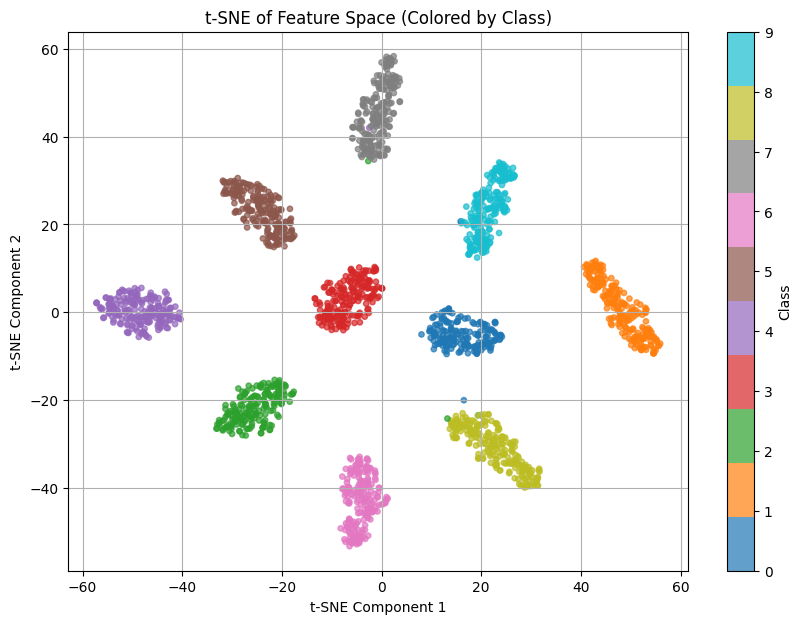

In [33]:
num_samples = 2000
indices = np.random.choice(len(train_feature_space), size=num_samples, replace=False)

sampled_features = train_feature_space[indices]
sampled_labels = torch.tensor([trainset[i][1] for i in indices])

tsne = TSNE(n_components=2, random_state=42)
reduced_space = tsne.fit_transform(sampled_features.cpu().numpy())

plt.figure(figsize=(10, 7))
scatter = plt.scatter(reduced_space[:, 0], reduced_space[:, 1], c=sampled_labels, cmap='tab10', s=15, alpha=0.7)
plt.colorbar(scatter, ticks=range(10), label='Class')
plt.title("t-SNE of Feature Space (Colored by Class)")
plt.xlabel("t-SNE Component 1")
plt.ylabel("t-SNE Component 2")
plt.grid(True)
plt.show()

### Feature Map


In this part, we are going to visualize the output of one of the convolutional layers to see what features they focus on.

First, let's select a random image from dataset.

In [37]:
image = trainset[3][0].to(device)

Now, we are going to *clip* our model at different points to get different intermediate representation.
* Clip your model at least at one point and plot the filters output. You can use the output of first Resnet block.

In order to clip the model, you can use `model.children()` method. For example, to get output only after the first 2 layers, you can do:

```
clipped = nn.Sequential(
    *list(model.children()[:2])
)
intermediate_output = clipped(input)
```



In [38]:
model.to(device)
image = image.to(device)

image = image.unsqueeze(0)

clipped = nn.Sequential(
    *list(model.feature_learning.children())[:4]
)

model.eval()
with torch.no_grad():
    intermediate_output = clipped(image)

In [39]:
intermediate_output.shape

torch.Size([1, 128, 32, 32])

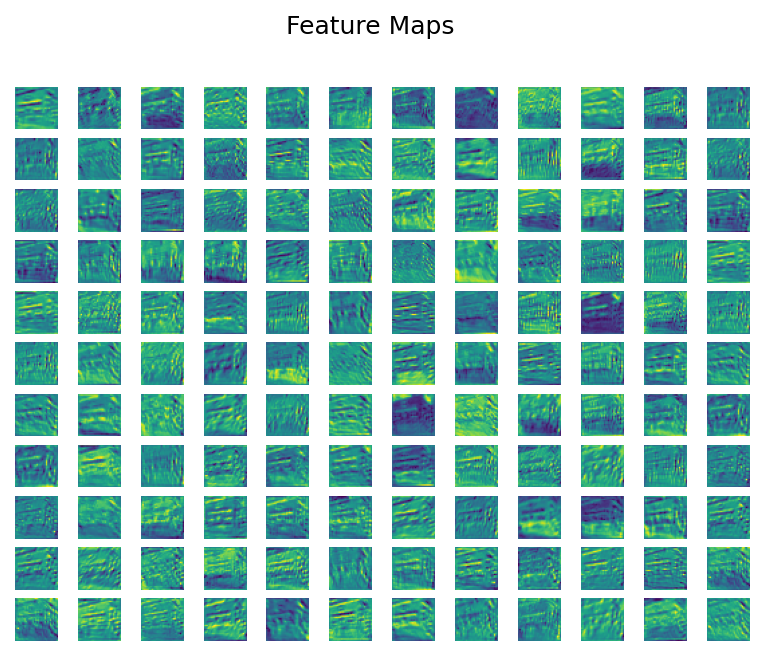

In [41]:
import matplotlib.pyplot as plt

def plot_intermediate_output(result, title=None):
    """
    Plots the intermediate output of shape
    N_FILTERS x H x W
    """
    plt.rcParams['figure.dpi'] = 150
    n_filters = result.shape[1]
    N = int(math.sqrt(n_filters))
    M = (n_filters + N - 1) // N
    assert N * M >= n_filters

    fig, axs = plt.subplots(N, M)
    fig.suptitle(title)

    for i in range(N):
        for j in range(M):
            if i*N + j < n_filters:
                axs[i][j].imshow(result[0, i*N + j].cpu().detach())
                axs[i][j].axis('off')

plot_intermediate_output(intermediate_output, title='Feature Maps')


**Note:** You are expected to analyze all results presented in this notebook and thoughtfully consider the underlying reasons behind them. Be prepared to discuss your insights during the **in-person review session**.
A written report is not required.
